In [246]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from IPython.display import display, Markdown
from matplotlib import gridspec 

# Visualization settings
%matplotlib inline


try:
    plt.style.use('seaborn-v0_8')  
except:
    plt.style.use('seaborn')       
    print("Note: Using legacy 'seaborn' style. Upgrade matplotlib for better results.")

sns.set_palette("husl")

pd.set_option('display.max_columns', 50)

TEMPERATURE_THRESHOLD_HIGH = 30  
TEMPERATURE_THRESHOLD_LOW = 10   
HUMIDITY_THRESHOLD = 80          

In [247]:
def load_and_preprocess_data():
    """Load and preprocess logistics IoT data."""
    try:
        df = pd.read_csv(
            "smart_logistics_tracking_data.csv",
            parse_dates=['timestamp']  
        )
        
        # Handle missing data
        if df.isnull().sum().sum() > 0:
            display(Markdown("**⚠️ Missing Values Detected:**"))
            display(df.isnull().sum())
            
            # Impute missing values
            df['temperature_celsius'].fillna(df['temperature_celsius'].median(), inplace=True)
            df['humidity_percentage'].fillna(df['humidity_percentage'].mean(), inplace=True)
        
        # Feature engineering
        df['time_of_day'] = df['timestamp'].dt.hour
        df['is_weekend'] = df['timestamp'].dt.dayofweek >= 5
        df['temperature_alert'] = np.where(
            (df['temperature_celsius'] > TEMPERATURE_THRESHOLD_HIGH) | 
            (df['temperature_celsius'] < TEMPERATURE_THRESHOLD_LOW),
            'Alert', 'Normal'
        )
        
        return df
    
    except Exception as e:
        print(f"❌ Error loading data: {e}")
        return None

# Load data
df = load_and_preprocess_data()
display(df.head(3))

,timestamp,package_id,location,temperature_celsius,status,time_of_day,is_weekend,temperature_alert
0,2025-05-10 02:06:18.473232,PKG6928,Pasig,20.4,delayed,2,True,Normal
1,2025-05-10 09:23:18.474489,PKG7988,Pasay,21.1,in transit,9,True,Normal
2,2025-05-10 20:42:18.474527,PKG1751,Pasig,27.5,delivered,20,True,Normal


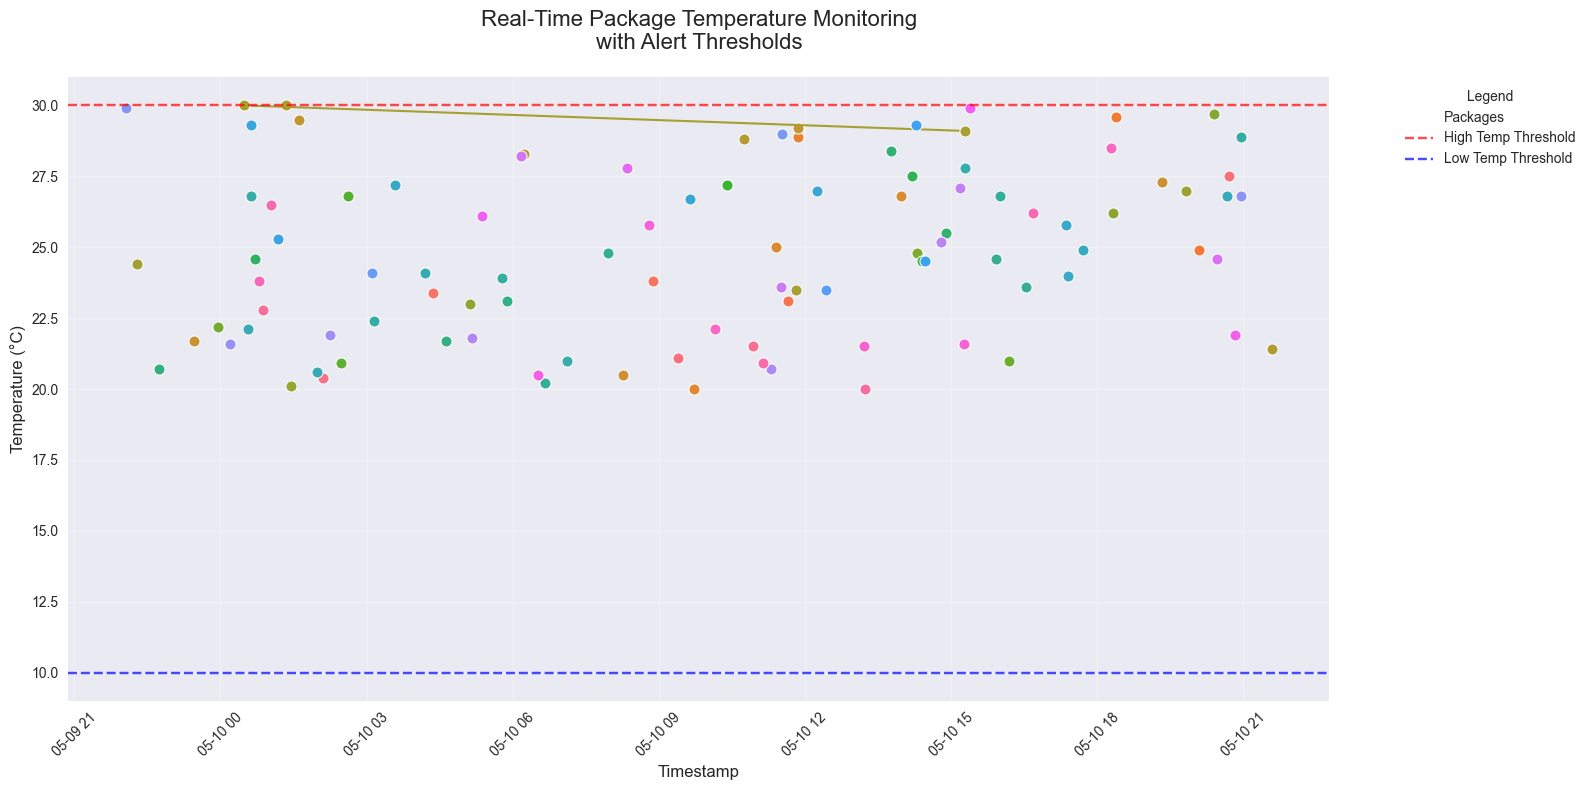

In [248]:
plt.figure(figsize=(16, 8))

package_palette = sns.color_palette("husl", n_colors=len(df['package_id'].unique()))

ax = sns.lineplot(
    data=df,
    x="timestamp",
    y="temperature_celsius",
    hue="package_id",
    style="temperature_alert",
    markers=True,
    dashes=False,
    palette=package_palette,  # For package_ids
    markersize=8,
    linewidth=1.5
)


for line in ax.lines:
    if 'Alert' in line.get_label():
        line.set_color('red')
    elif 'Normal' in line.get_label():
        line.set_color('green')

# Threshold lines
ax.axhline(TEMPERATURE_THRESHOLD_HIGH, color='r', linestyle='--', alpha=0.7, label='High Temp Threshold')
ax.axhline(TEMPERATURE_THRESHOLD_LOW, color='b', linestyle='--', alpha=0.7, label='Low Temp Threshold')

# Formatting
plt.title("Real-Time Package Temperature Monitoring\nwith Alert Thresholds", fontsize=16, pad=20)
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.xticks(rotation=45)

handles, labels = ax.get_legend_handles_labels()
filtered_handles = [h for h in handles if not str(h).startswith('Line2D(_child')]
filtered_labels = [l for l in labels if not l.startswith('_')]

plt.legend(
    handles=filtered_handles[:1] + filtered_handles[-2:],
    labels=['Packages'] + filtered_labels[-2:],
    title='Legend',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Real-Time Package Status and temperature

## 📍 Location: Pasig

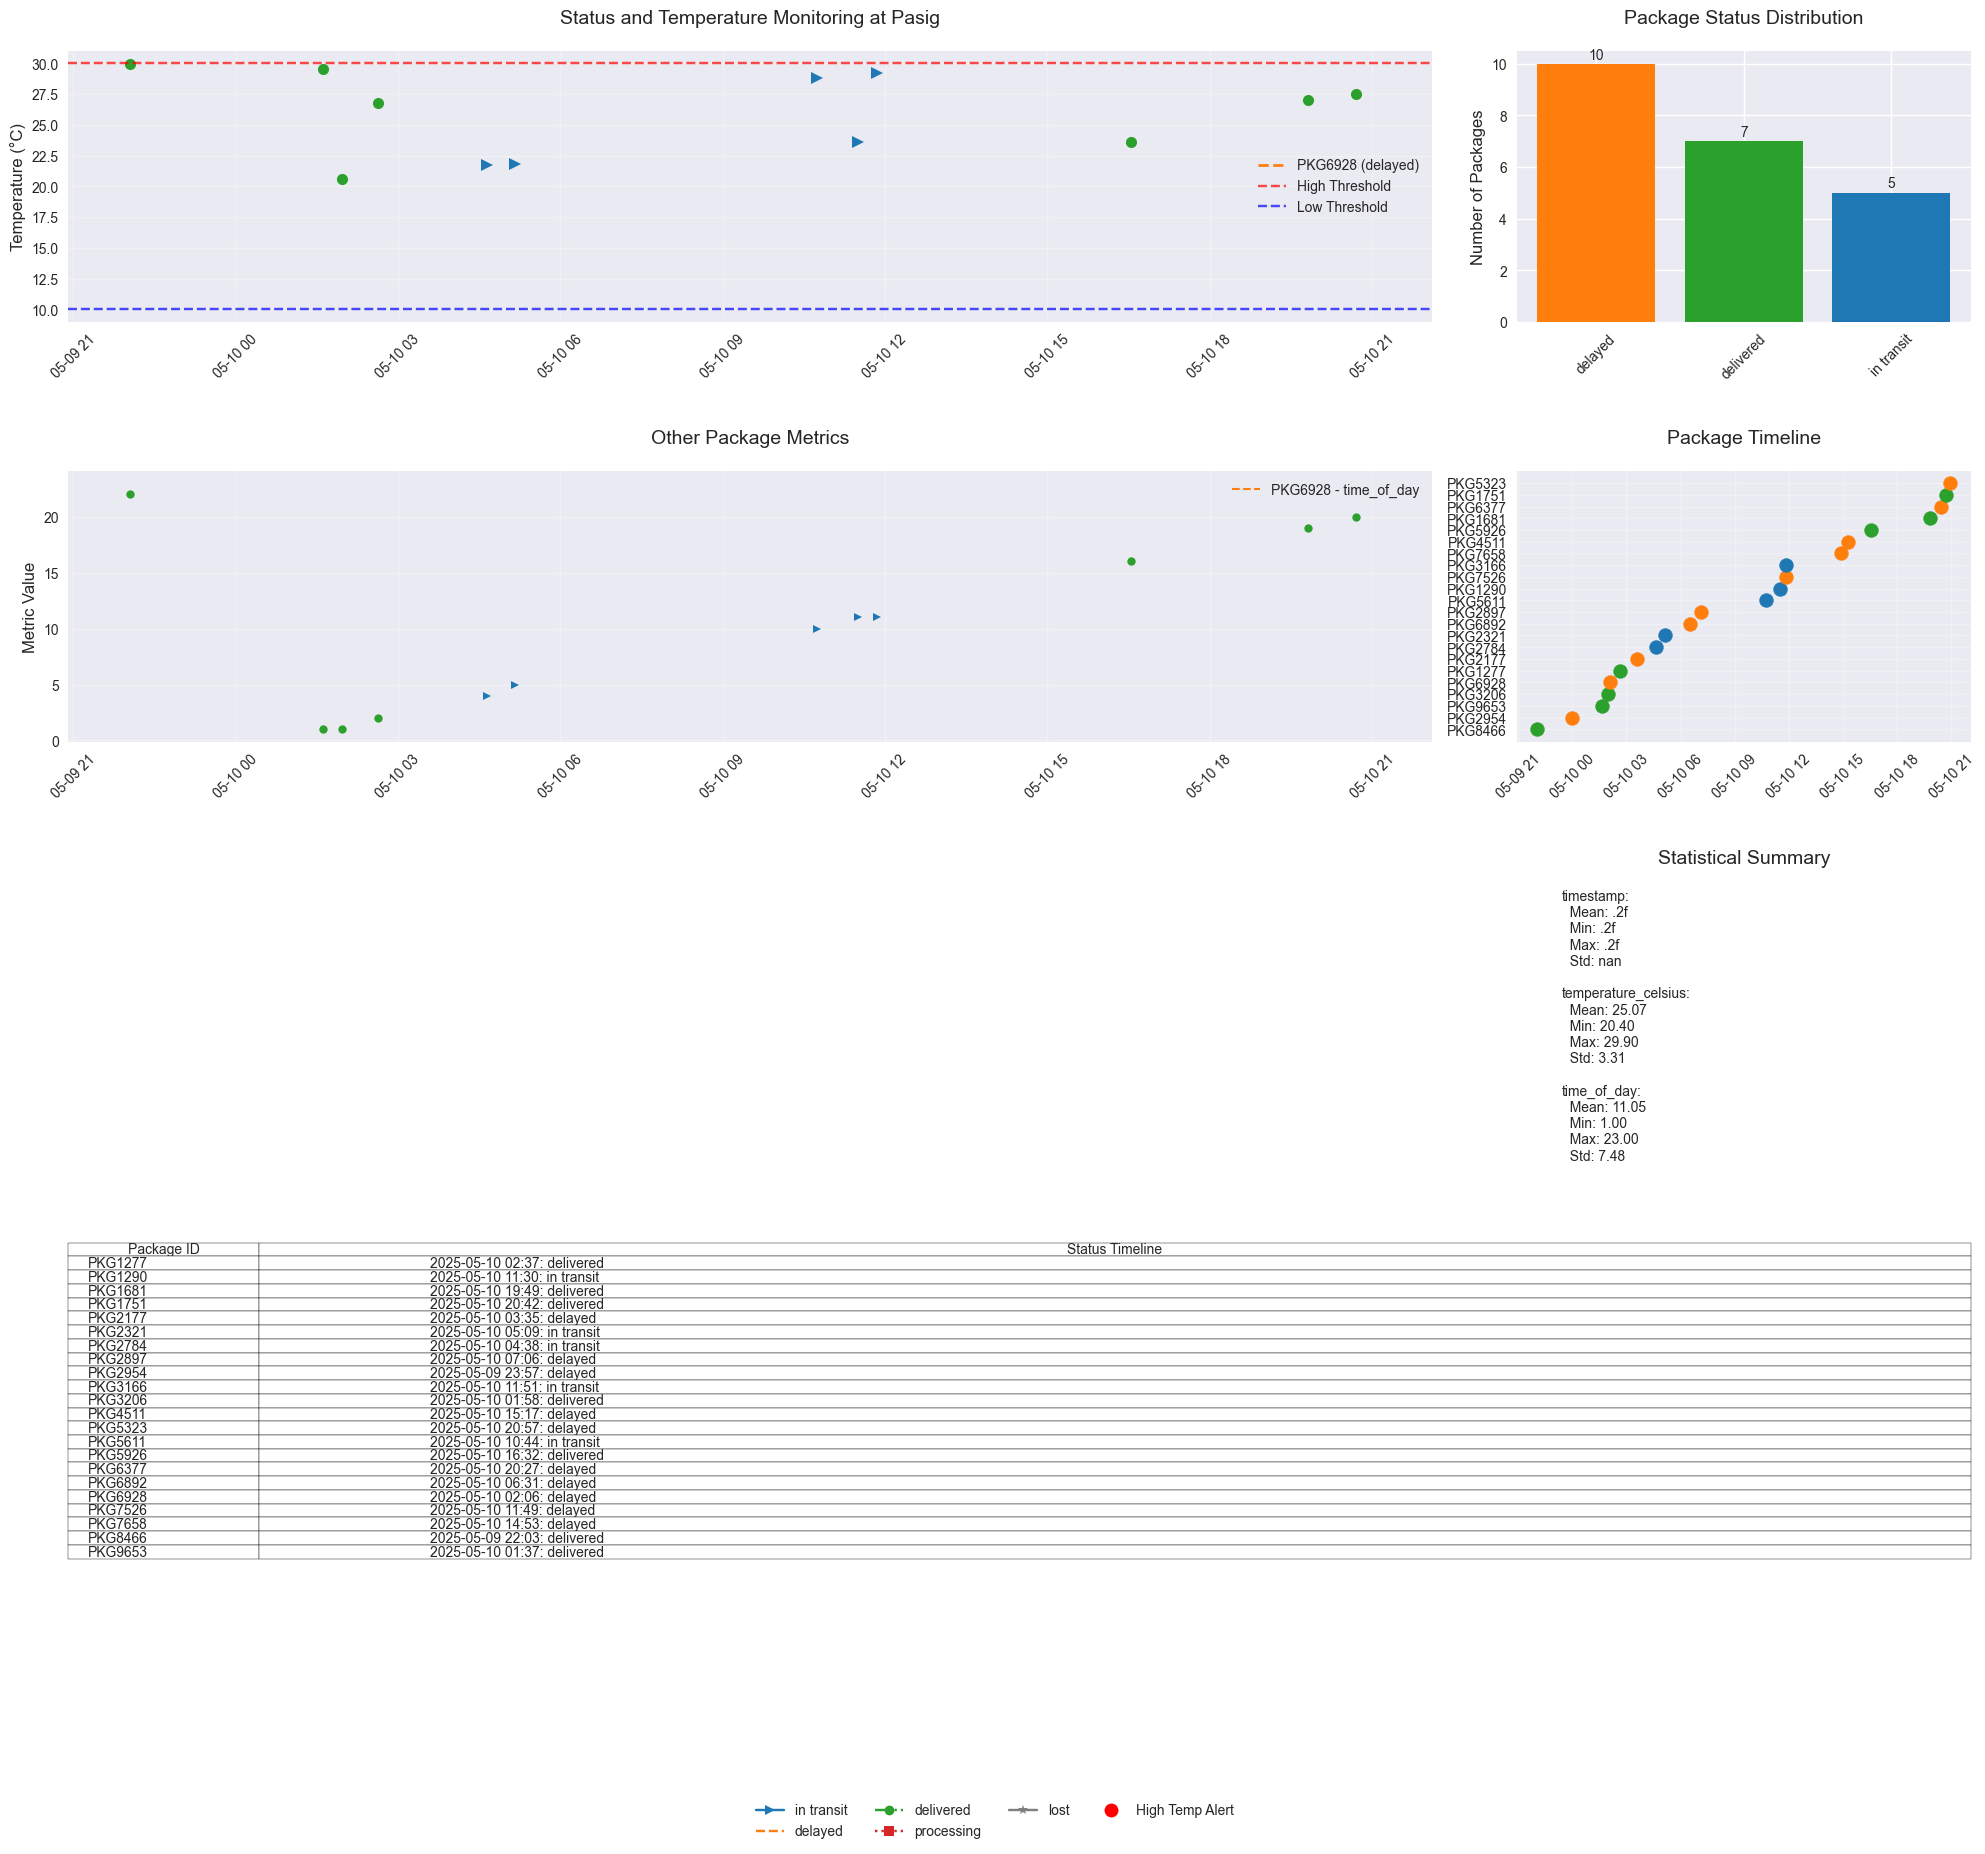

**Alert Summary:**
- Temperature alerts: 0


## 📍 Location: Pasay

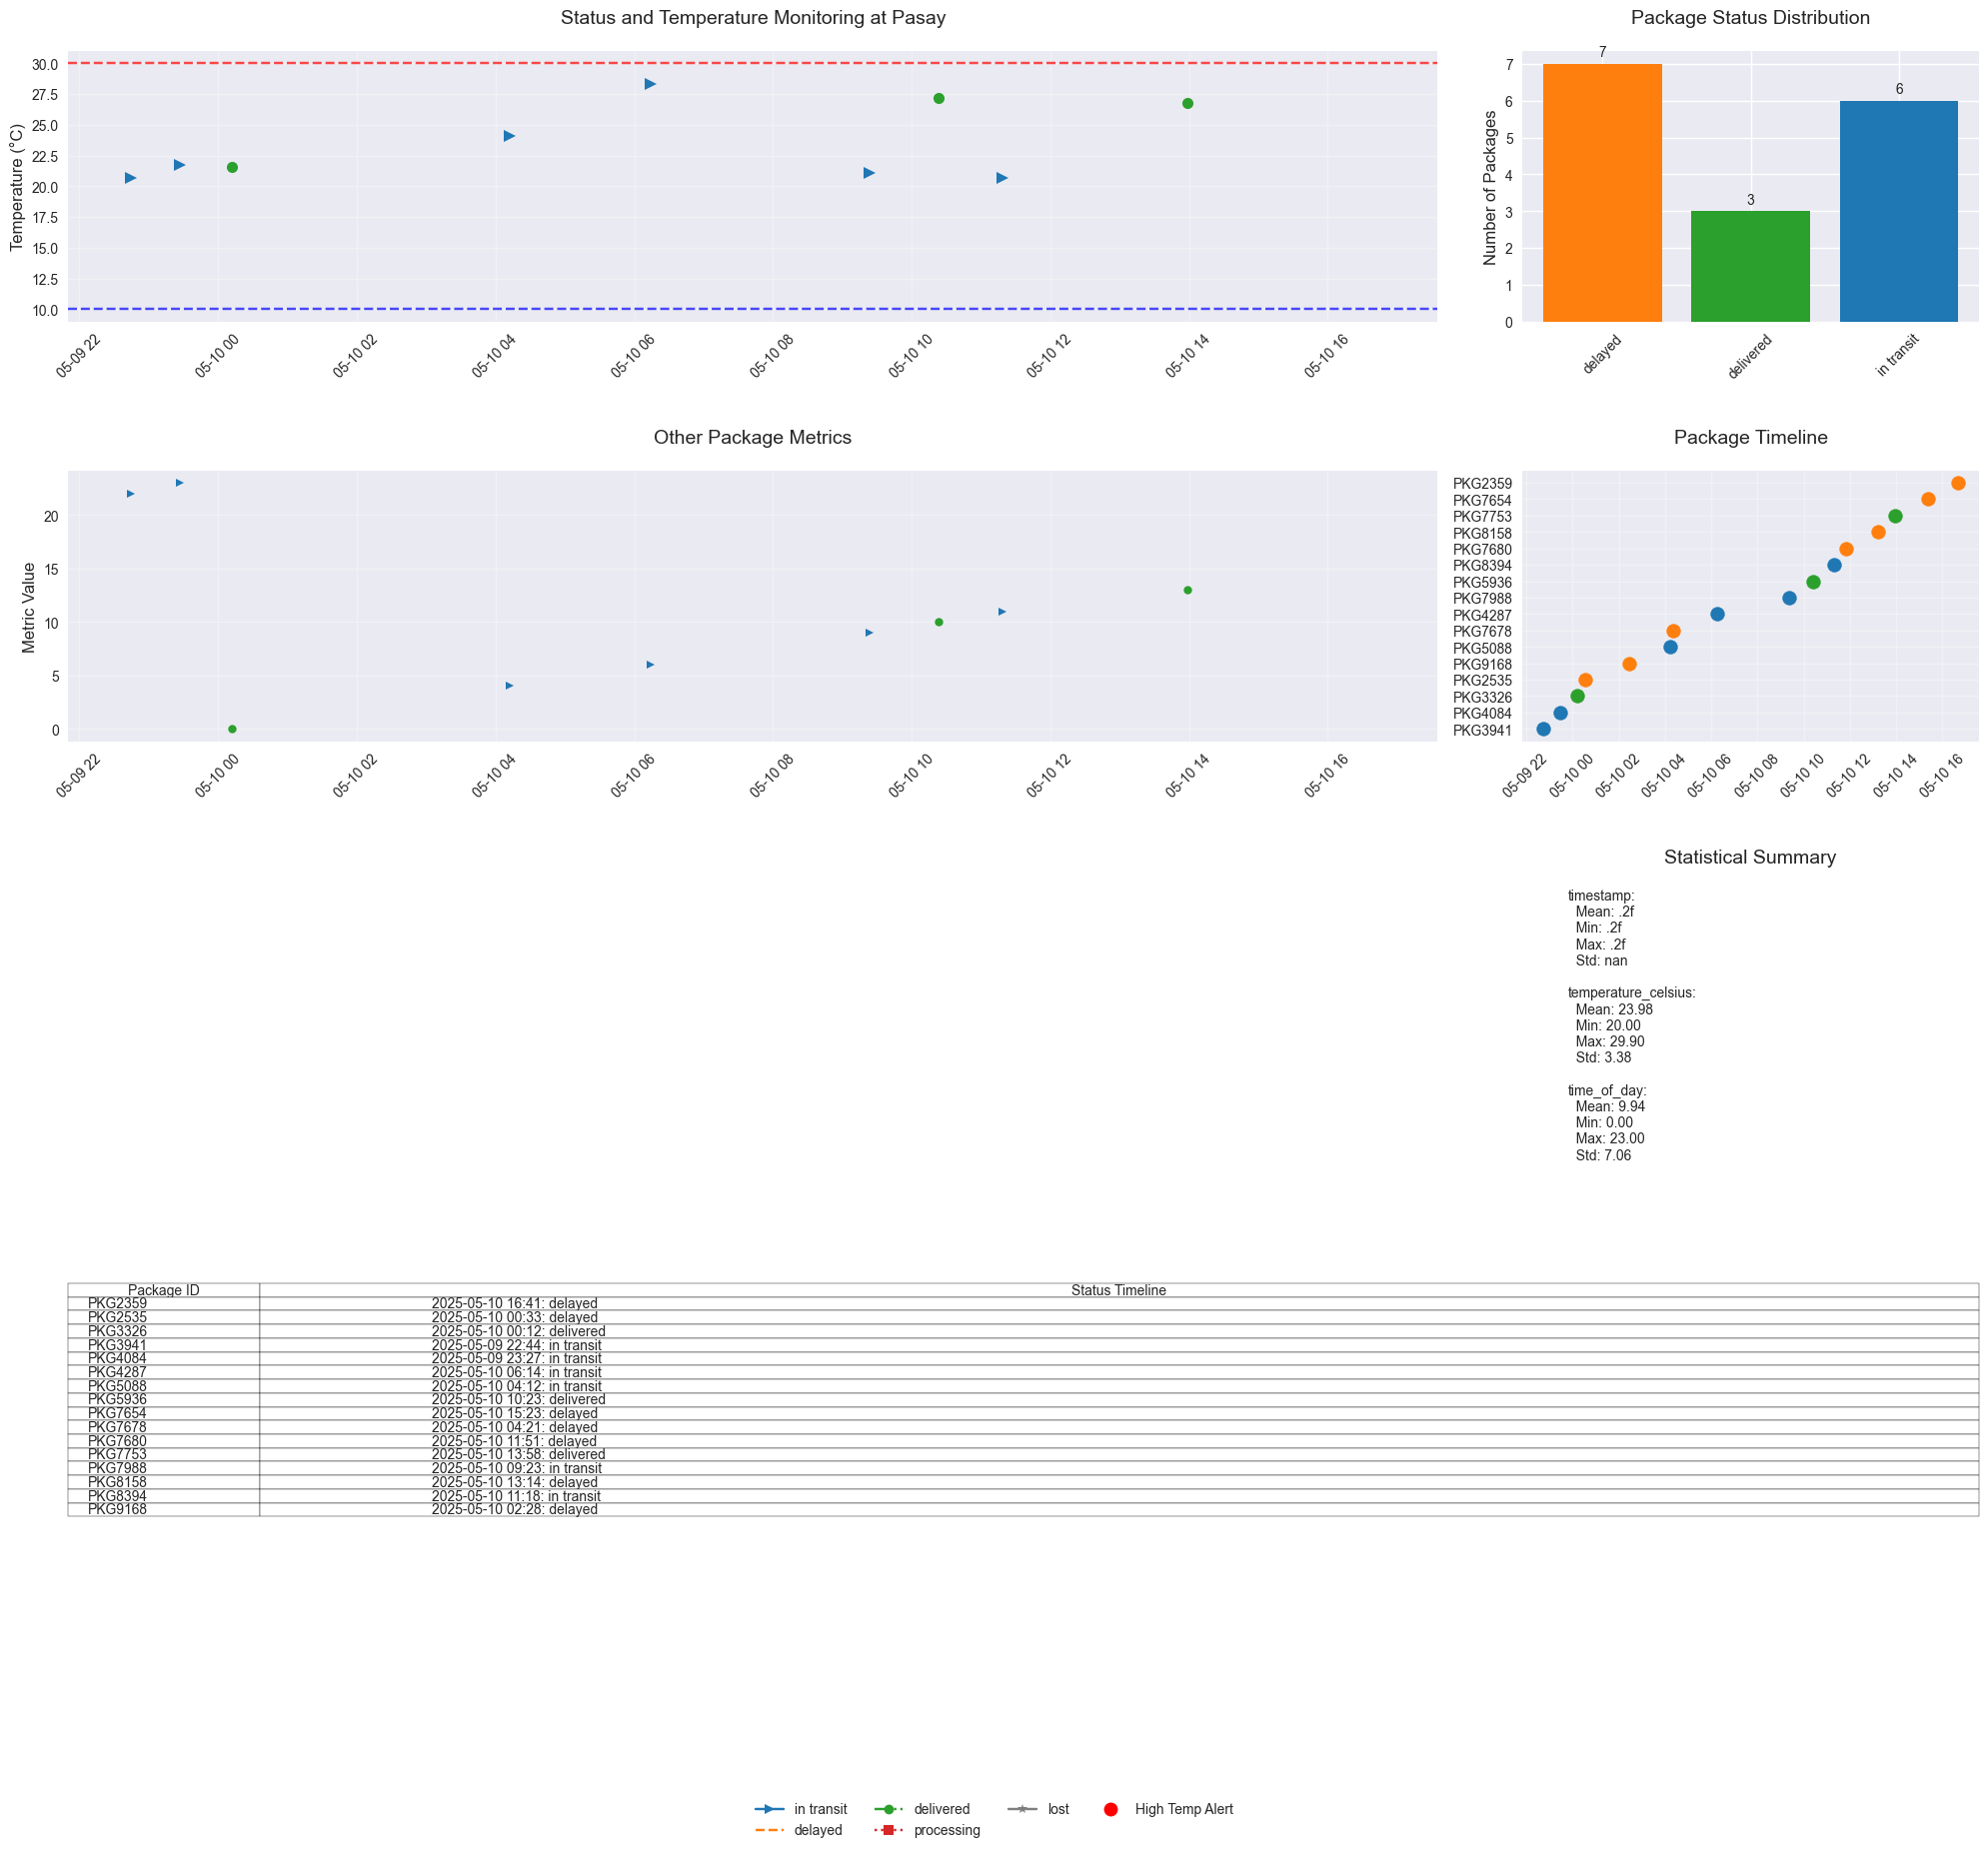

**Alert Summary:**
- Temperature alerts: 0


## 📍 Location: Caloocan

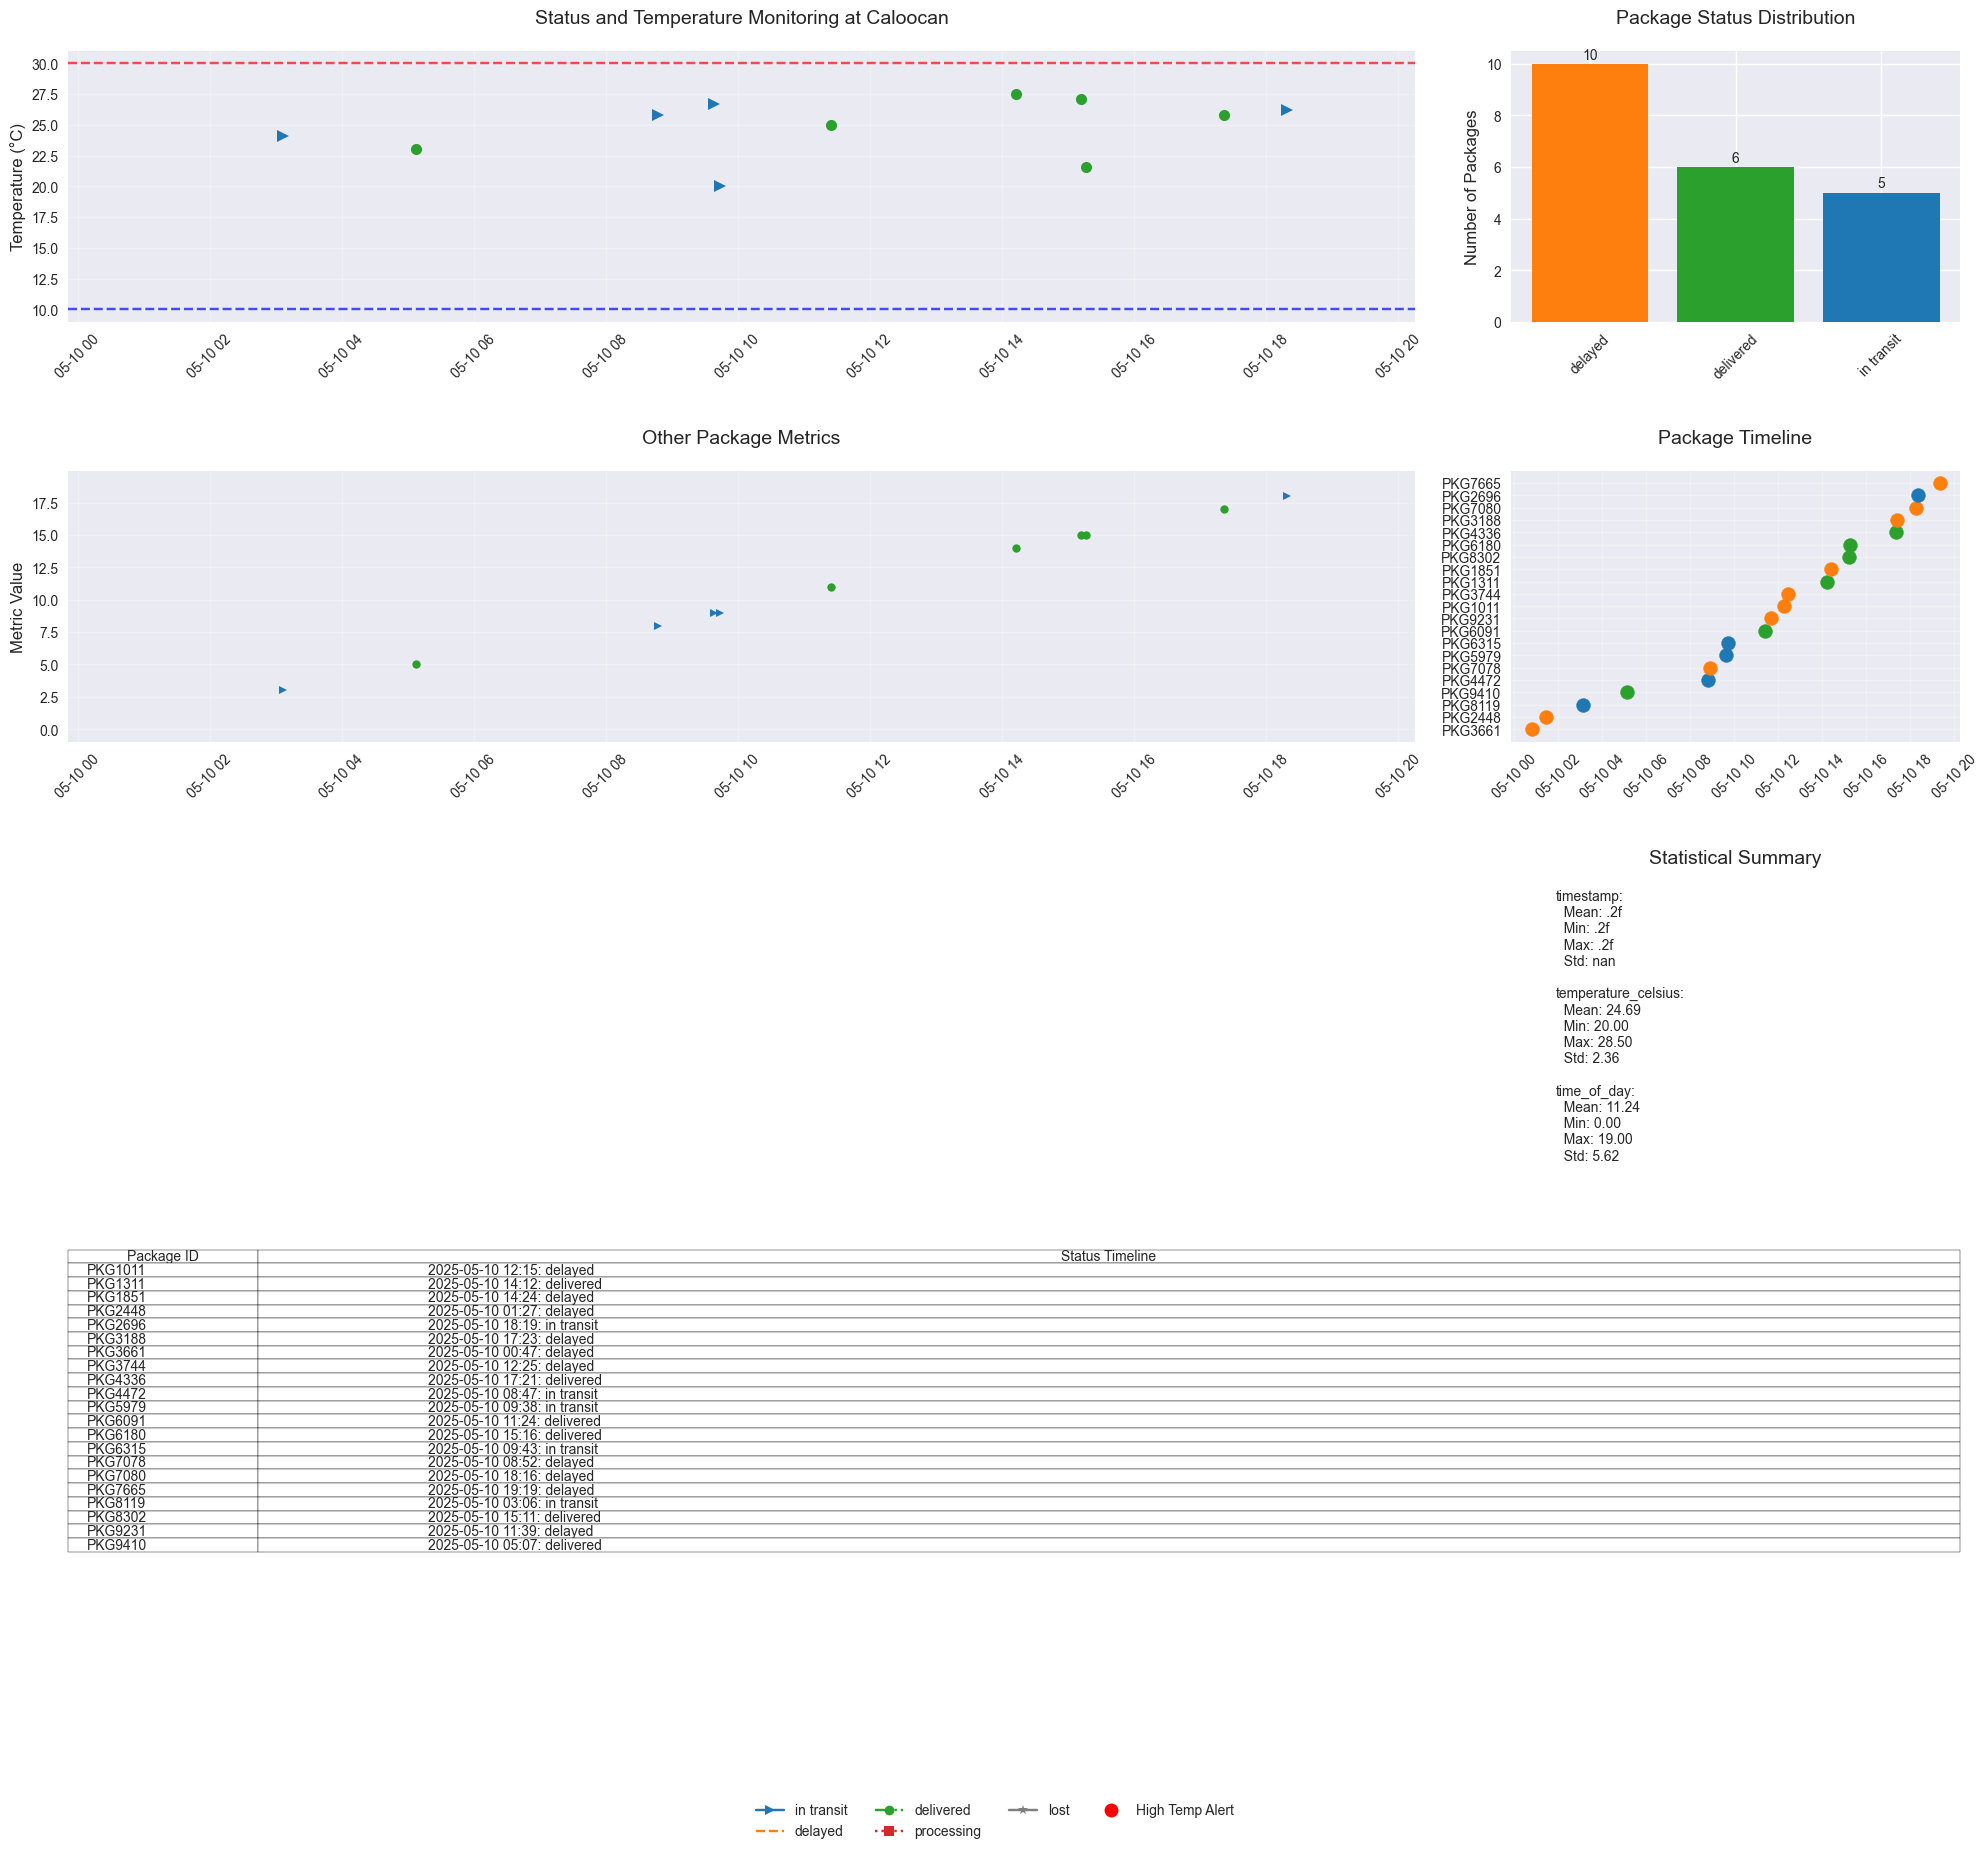

**Alert Summary:**
- Temperature alerts: 0


## 📍 Location: Manila

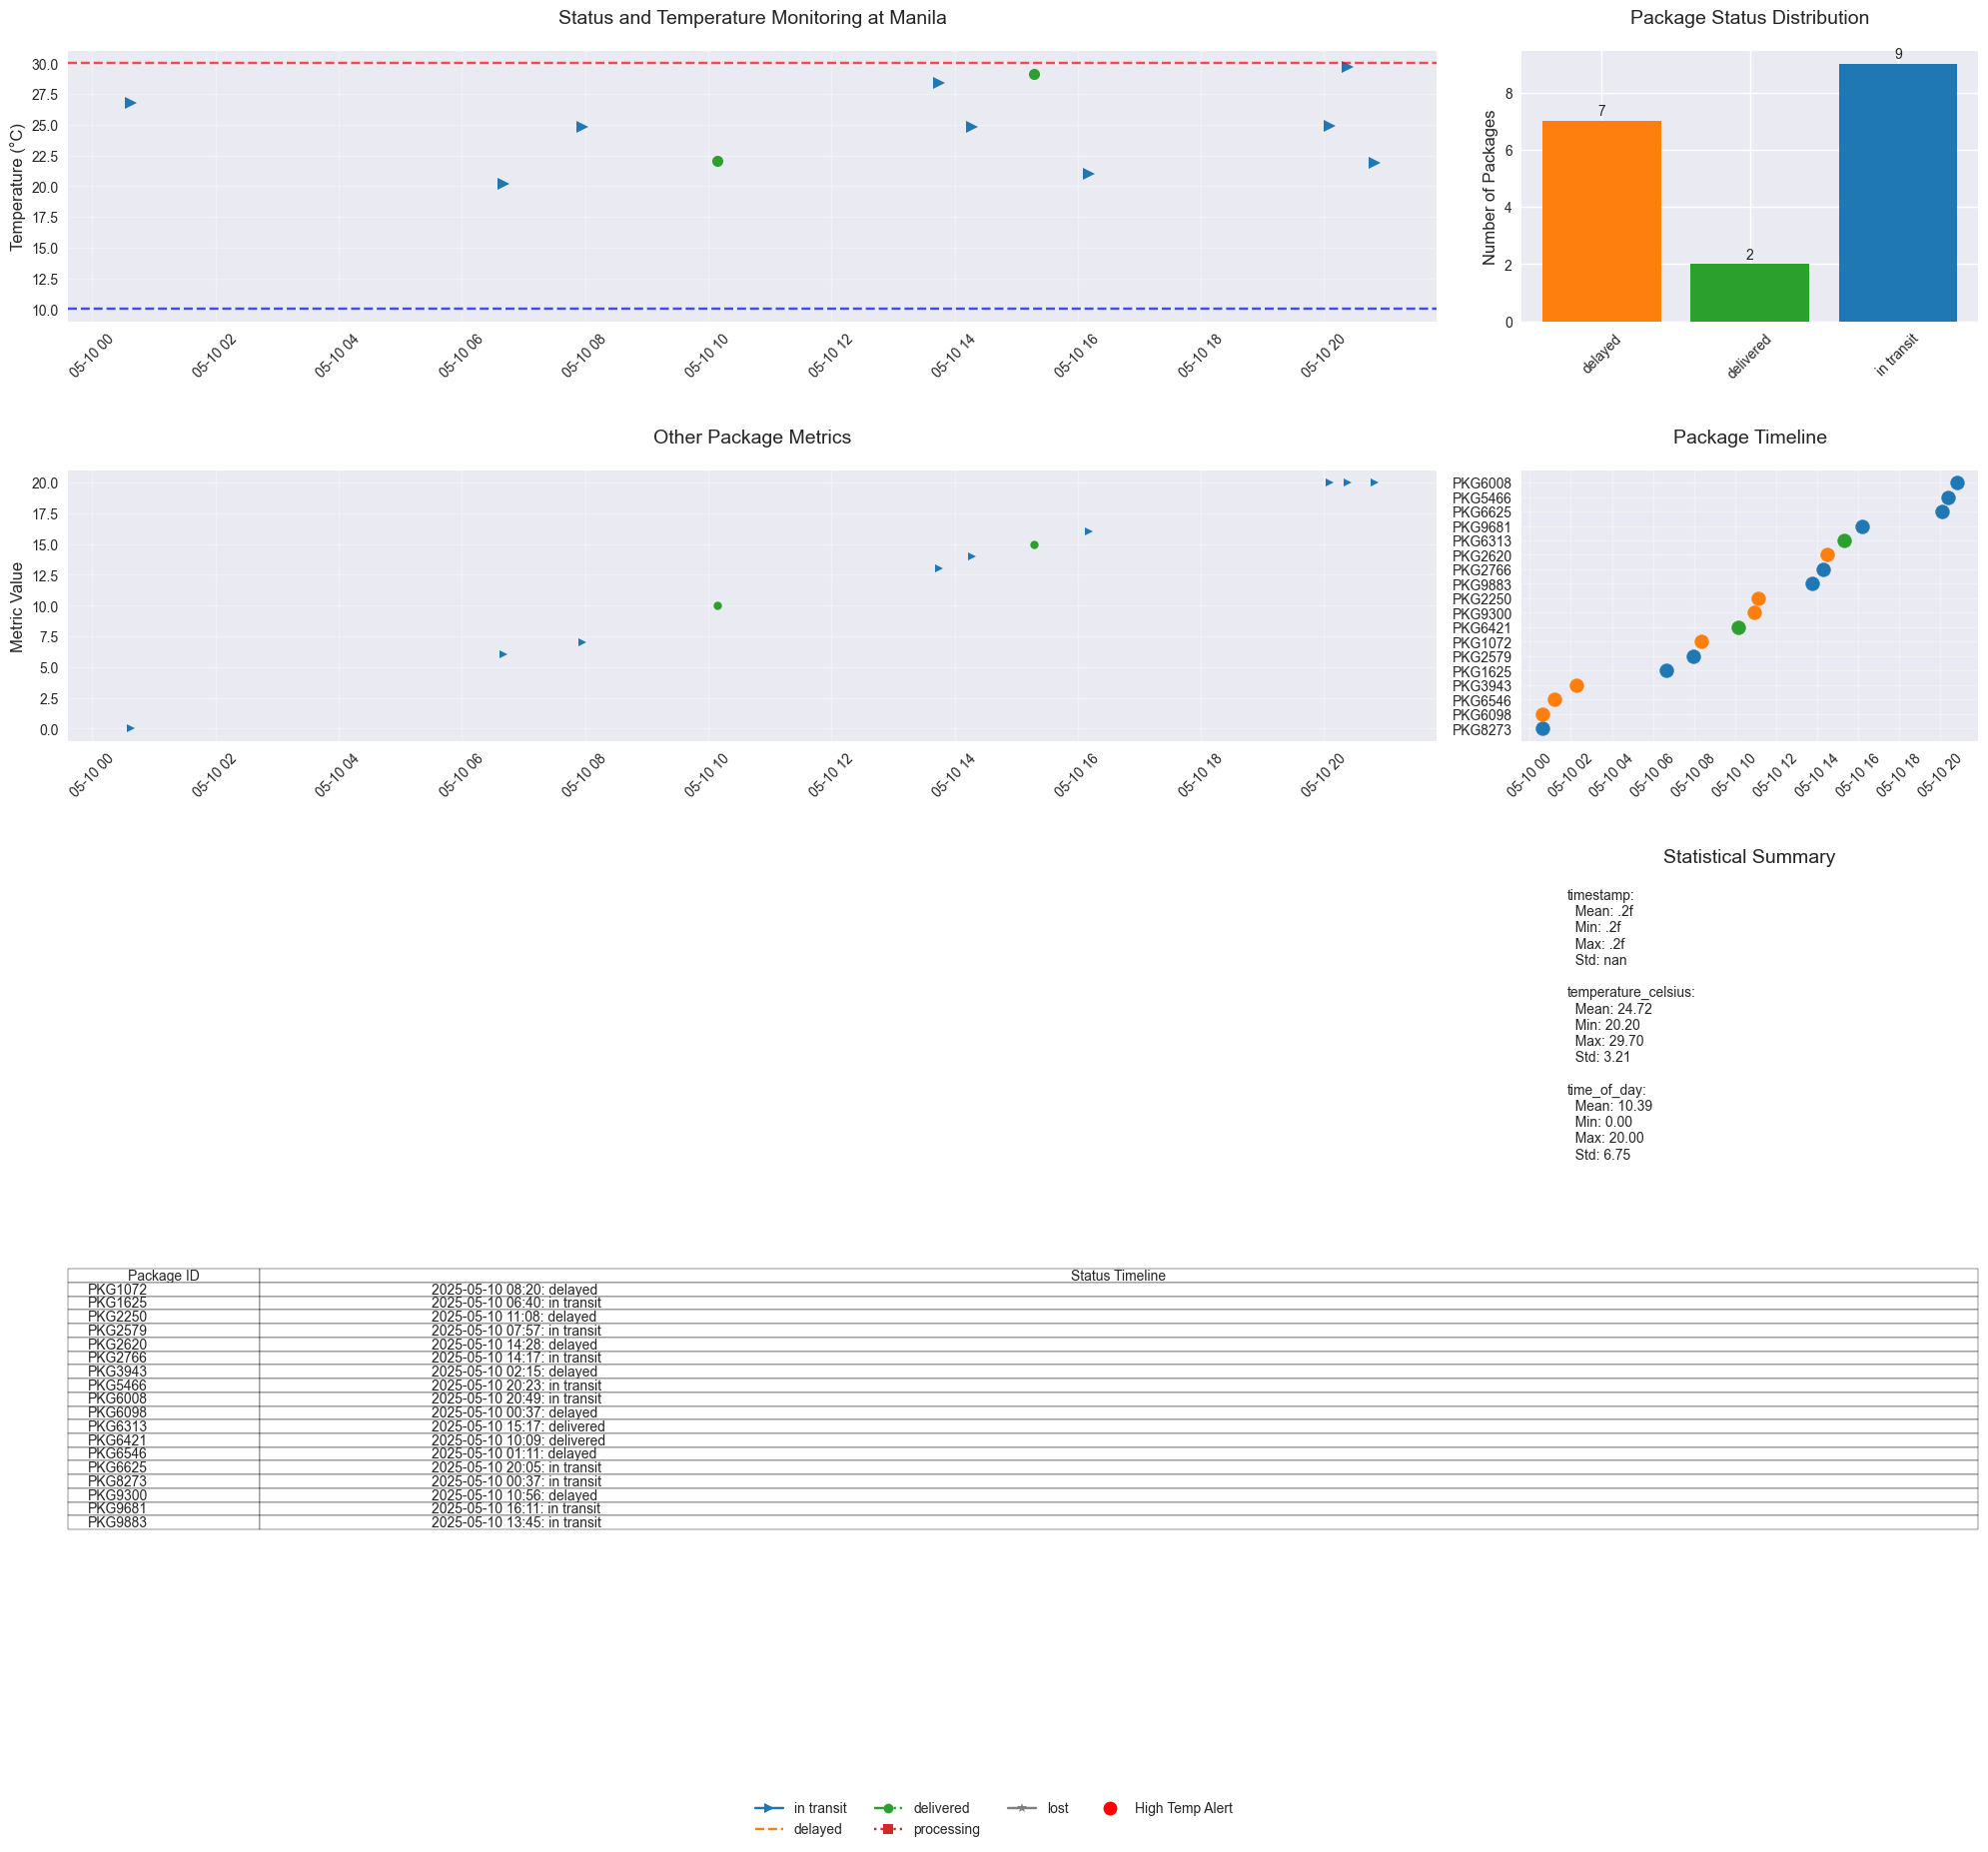

**Alert Summary:**
- Temperature alerts: 0


## 📍 Location: San Jose Bulacan

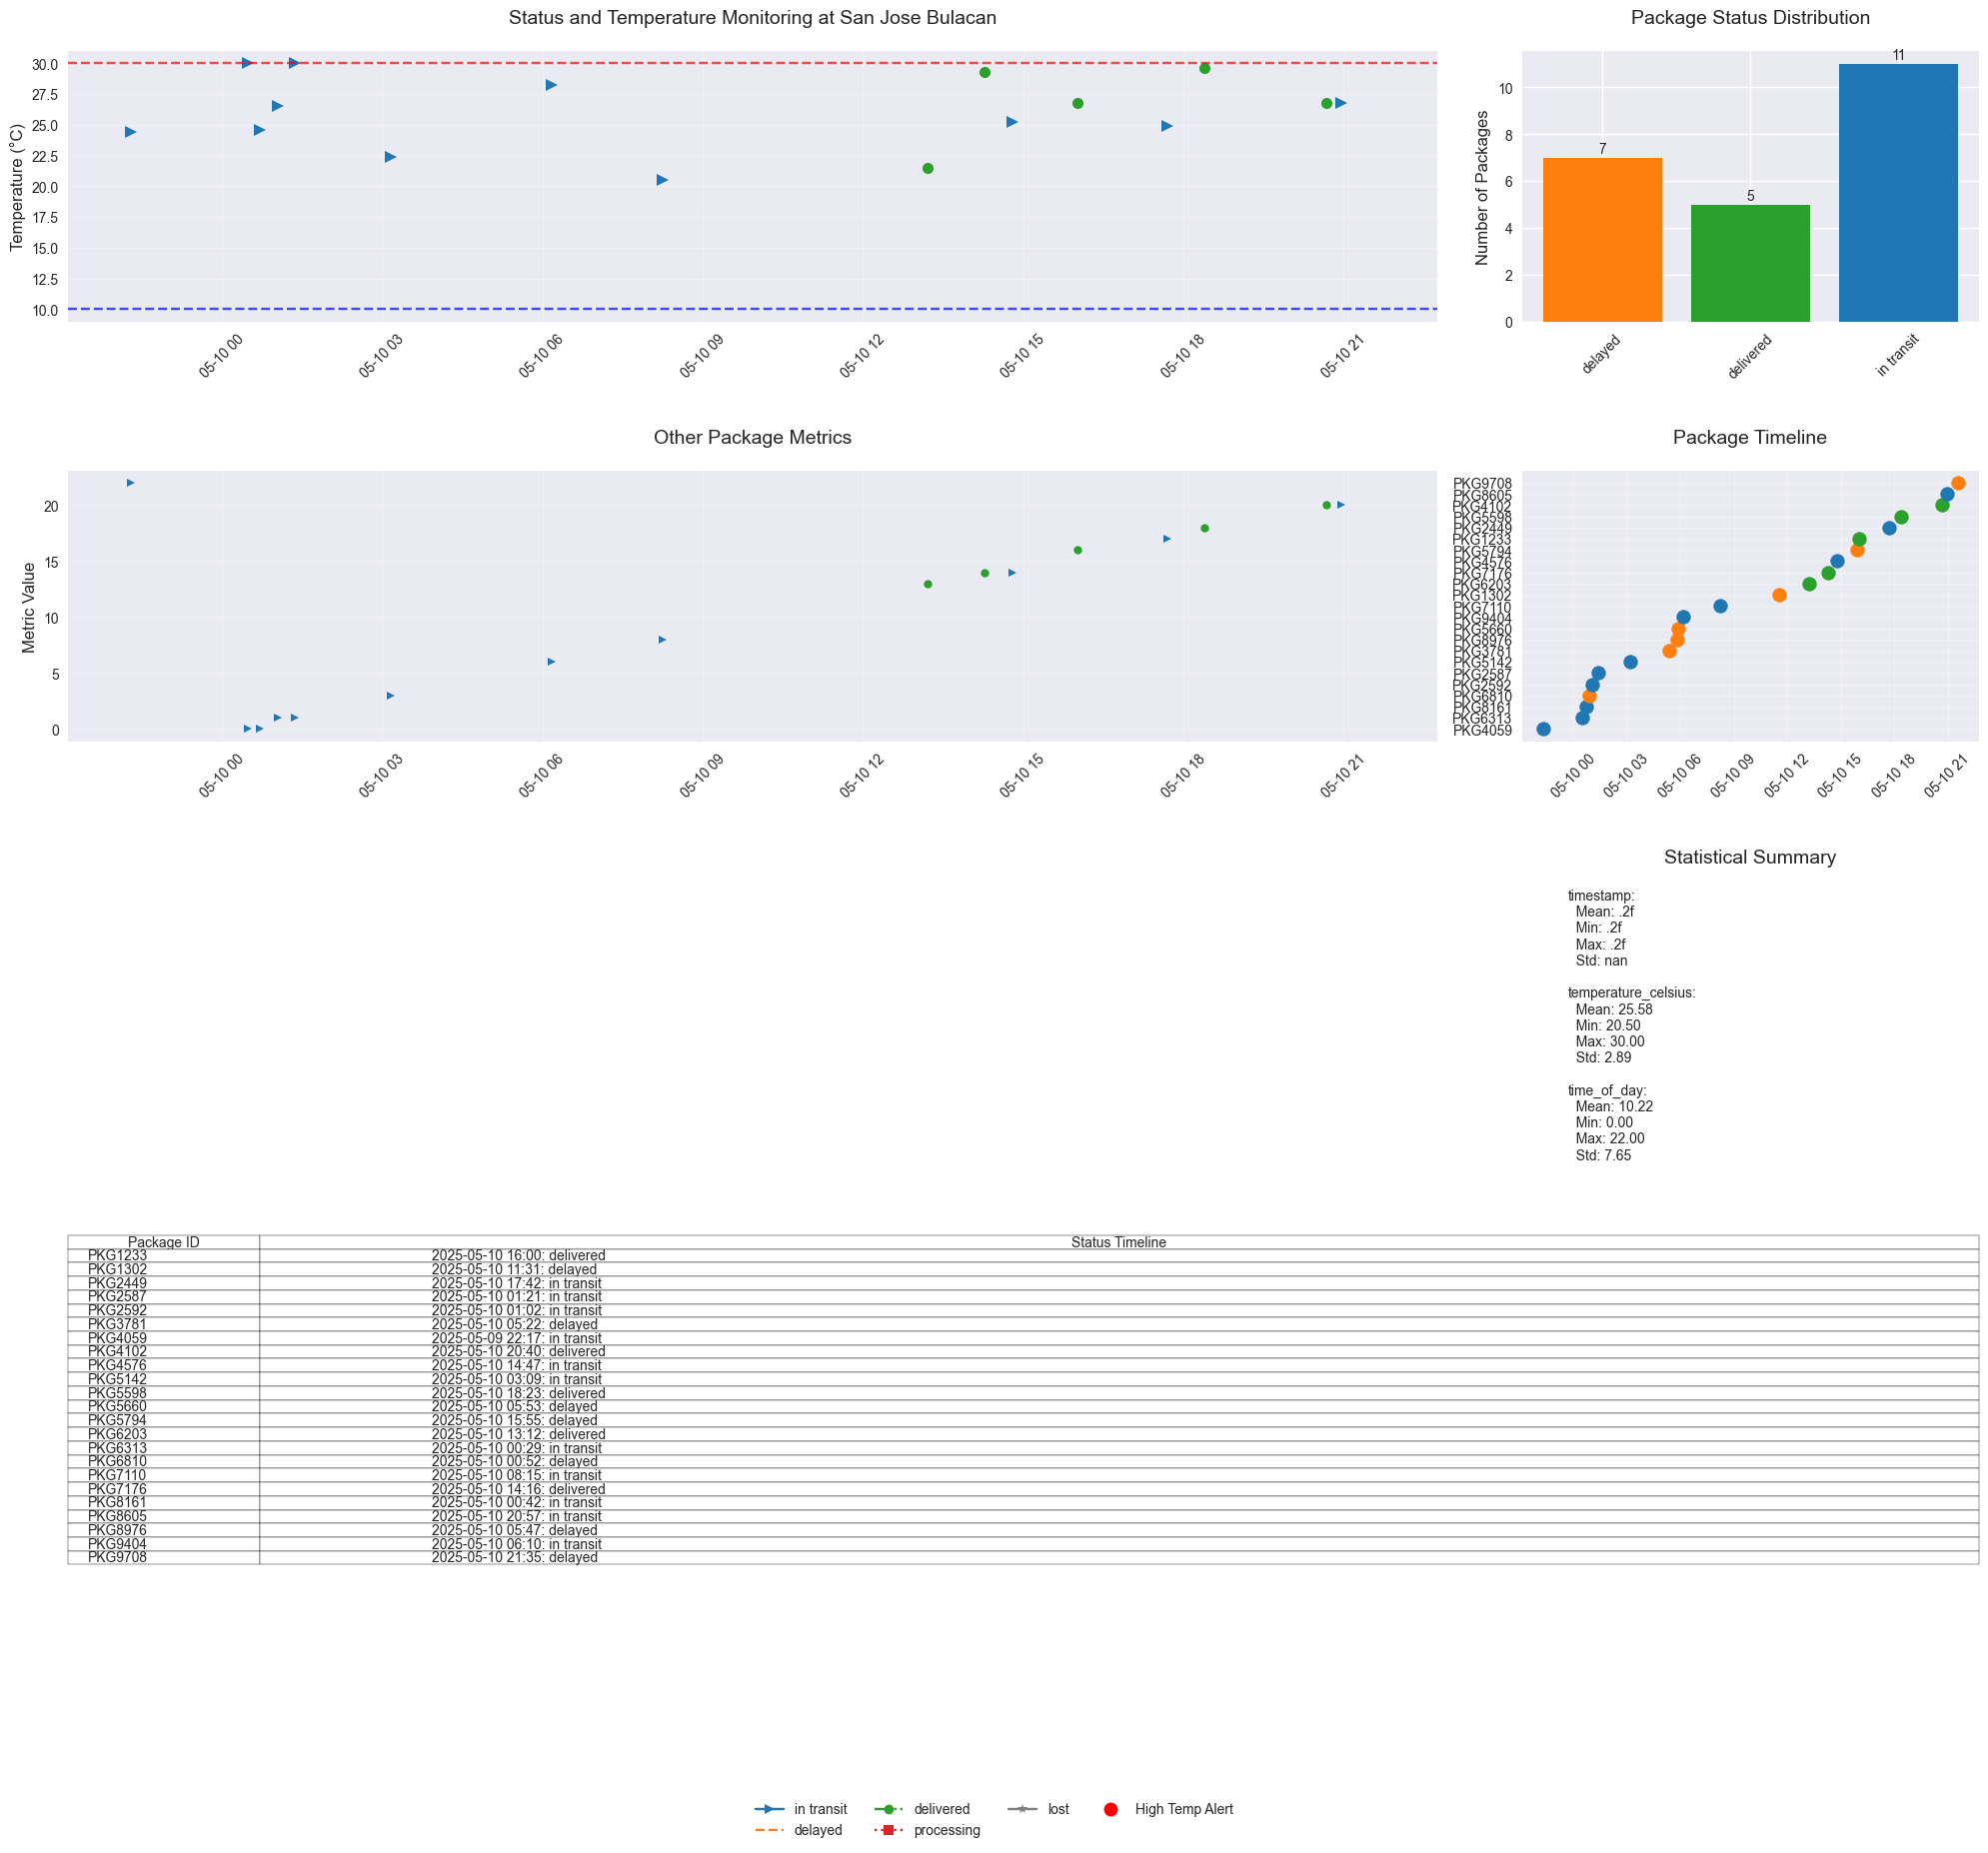

**Alert Summary:**
- Temperature alerts: 0


In [ ]:
display(Markdown("# Real-Time Package Status and temperature"))


status_styles = {
    'in transit': {'linestyle': '-', 'color': '#1f77b4', 'marker': '>'},  
    'delayed': {'linestyle': '--', 'color': '#ff7f0e', 'marker': 'x'},
    'delivered': {'linestyle': '-.', 'color': '#2ca02c', 'marker': 'o'},
    'processing': {'linestyle': ':', 'color': '#d62728', 'marker': 's'},
    'lost': {'linestyle': '-', 'color': '#7f7f7f', 'marker': '*'}
}

TEMPERATURE_THRESHOLD_HIGH = 30  
TEMPERATURE_THRESHOLD_LOW = 10   
HUMIDITY_THRESHOLD = 80          

for loc in df["location"].unique():
    display(Markdown(f"## 📍 Location: {loc}"))
    subset = df[df["location"] == loc].sort_values('timestamp')
    
    
    numeric_cols = subset.select_dtypes(include=['number']).columns.tolist()
    has_temperature = 'temperature_celsius' in numeric_cols
    has_humidity = 'humidity_percentage' in numeric_cols
    other_metrics = [col for col in numeric_cols 
                    if col not in ['temperature_celsius', 'humidity_percentage']]
    
    
    rows = 3 + (1 if len(other_metrics) > 0 else 0)
    height_ratios = [3, 3, 3, 2] if len(other_metrics) > 0 else [3, 3, 2]
    
    
    fig = plt.figure(figsize=(20, 18 if len(other_metrics) > 0 else 15))
    gs = gridspec.GridSpec(rows, 2, height_ratios=height_ratios, width_ratios=[3, 1])
    
    
    panel_idx = 0
    
    ## Panel 1: Temperature Tracking
    if has_temperature:
        ax1 = plt.subplot(gs[panel_idx, 0])
        panel_idx += 1
        
        unique_packages = subset['package_id'].unique()
        has_labels = False

        for pkg in unique_packages:
            pkg_data = subset[subset['package_id'] == pkg]
    
            
            status_changes = (pkg_data['status'] != pkg_data['status'].shift()).cumsum()
            
            for _, segment in pkg_data.groupby(status_changes):
                status = segment['status'].iloc[0]
                style = status_styles.get(status, {})

                label = f"{pkg} ({status})" if segment.index[0] == 0 else ""
                if label:
                    has_labels = True 
                
                ax1.plot(segment['timestamp'], segment['temperature_celsius'],
                        linestyle=style.get('linestyle', '-'),
                        color=style.get('color', '#333333'),
                        marker=style.get('marker', 'o'),
                        markersize=8,
                        linewidth=2,
                        label=f"{pkg} ({status})" if segment.index[0] == 0 else "")
                
                # Highlight threshold breaches
                breaches = segment[segment['temperature_celsius'] > TEMPERATURE_THRESHOLD_HIGH]
                if not breaches.empty:
                    ax1.scatter(breaches['timestamp'], breaches['temperature_celsius'],
                               color='red', s=100, edgecolor='black', zorder=5,
                               label='High Temp Alert' if segment.index[0] == 0 else "")
        
        ax1.axhline(TEMPERATURE_THRESHOLD_HIGH, color='r', linestyle='--', alpha=0.7, label='High Threshold')
        ax1.axhline(TEMPERATURE_THRESHOLD_LOW, color='b', linestyle='--', alpha=0.7, label='Low Threshold')
        ax1.set_title(f'Status and Temperature Monitoring at {loc}', fontsize=14, pad=20)
        ax1.set_ylabel('Temperature (°C)', fontsize=12)
        ax1.grid(True, alpha=0.3)
        ax1.tick_params(axis='x', rotation=45)
        if has_labels:
            ax1.legend()
    
    ## Panel 2: Humidity Tracking
    if has_humidity:
        ax2 = plt.subplot(gs[panel_idx, 0])
        panel_idx += 1
        
        has_labels = False

        for pkg in unique_packages:
            pkg_data = subset[subset['package_id'] == pkg]
            status_changes = (pkg_data['status'] != pkg_data['status'].shift()).cumsum()
            
            for _, segment in pkg_data.groupby(status_changes):
                status = segment['status'].iloc[0]
                style = status_styles.get(status, {})
                
                ax2.plot(segment['timestamp'], segment['humidity_percentage'],
                        linestyle=style.get('linestyle', '-'),
                        color=style.get('color', '#333333'),
                        marker=style.get('marker', 'o'),
                        markersize=8,
                        linewidth=2)
                
                # Highlight humidity breaches
                breaches = segment[segment['humidity_percentage'] > HUMIDITY_THRESHOLD]
                if not breaches.empty:
                    breach_labels = 'High Humidity Alert' if segment.index[0] == 0 else ""
                    if breach_labels:
                        has_labels = True
                    ax2.scatter(breaches['timestamp'], breaches['humidity_percentage'],
                               color='purple', s=100, edgecolor='black', zorder=5,
                               label='High Humidity Alert' if segment.index[0] == 0 else "")
        
        ax2.axhline(HUMIDITY_THRESHOLD, color='purple', linestyle='--', alpha=0.7, label='Humidity Threshold')
        ax2.set_title(f'Humidity Monitoring at {loc}', fontsize=14, pad=20)
        ax2.set_ylabel('Humidity (%)', fontsize=12)
        ax2.grid(True, alpha=0.3)
        ax2.tick_params(axis='x', rotation=45)
        if has_labels:
            ax2.legend()
    
    ## Panel 3: Other Metrics
    if len(other_metrics) > 0:
        ax3 = plt.subplot(gs[panel_idx, 0])
        panel_idx += 1
        
        has_labels = False

        for i, metric in enumerate(other_metrics):
            for pkg in unique_packages:
                pkg_data = subset[subset['package_id'] == pkg]
                status_changes = (pkg_data['status'] != pkg_data['status'].shift()).cumsum()
                
                for _, segment in pkg_data.groupby(status_changes):
                    status = segment['status'].iloc[0]
                    style = status_styles.get(status, {})

                    label = f"{pkg} - {metric}" if segment.index[0] == 0 else ""
                    if label:
                        has_labels = True 
                    
                    ax3.plot(segment['timestamp'], segment[metric],
                            linestyle=style.get('linestyle', '-'),
                            color=style.get('color', f'C{i}'),
                            marker=style.get('marker', 'o'),
                            markersize=6,
                            linewidth=1.5,
                            label=f"{pkg} - {metric}" if segment.index[0] == 0 else "")
        
        ax3.set_title('Other Package Metrics', fontsize=14, pad=20)
        ax3.set_ylabel('Metric Value', fontsize=12)
        ax3.grid(True, alpha=0.3)
        ax3.tick_params(axis='x', rotation=45)
        if has_labels:
            ax3.legend()
    
    ## Right Side Panels 
    # Panel 4: Status Distribution
    ax4 = plt.subplot(gs[0, 1])
    status_counts = subset.groupby('status')['package_id'].nunique().reset_index()
    colors = [status_styles.get(s, {}).get('color', '#333333') for s in status_counts['status']]
    ax4.bar(status_counts['status'], status_counts['package_id'], color=colors)
    ax4.set_title('Package Status Distribution', fontsize=14, pad=20)
    ax4.set_ylabel('Number of Packages', fontsize=12)
    ax4.tick_params(axis='x', rotation=45)
    
    for i, v in enumerate(status_counts['package_id']):
        ax4.text(i, v + 0.2, str(v), ha='center')
    
    # Panel 5: Package Timeline
    ax5 = plt.subplot(gs[1, 1])
    packages = subset['package_id'].unique()
    y_pos = np.arange(len(packages))
    
    for i, pkg in enumerate(packages):
        pkg_data = subset[subset['package_id'] == pkg]
        start = pkg_data['timestamp'].min()
        end = pkg_data['timestamp'].max()
        
        ax5.hlines(y=i, xmin=start, xmax=end, 
                  color='#1f77b4', linewidth=3)
        
        
        status_changes = pkg_data[pkg_data['status'] != pkg_data['status'].shift()]
        for _, row in status_changes.iterrows():
            ax5.scatter(row['timestamp'], i, 
                       color=status_styles.get(row['status'], {}).get('color', '#333333'),
                       s=100, zorder=3)
    
    ax5.set_yticks(y_pos)
    ax5.set_yticklabels(packages)
    ax5.set_title('Package Timeline', fontsize=14, pad=20)
    ax5.grid(True, alpha=0.3)
    ax5.tick_params(axis='x', rotation=45)
    
    # Panel 6: Statistical Summary
    ax6 = plt.subplot(gs[2, 1])
    stats = subset.describe().drop('count', errors='ignore').T  # Added error handling
    stats_text = []
    for col in stats.index:
        stats_text.append(f"{col}:\n"
                         f"  Mean: {stats.loc[col, 'mean']:.2f}\n"
                         f"  Min: {stats.loc[col, 'min']:.2f}\n"
                         f"  Max: {stats.loc[col, 'max']:.2f}\n"
                         f"  Std: {stats.loc[col, 'std']:.2f}")
    
    ax6.text(0.1, 0.5, "\n\n".join(stats_text), 
            va='center', ha='left', fontsize=10)
    ax6.axis('off')
    ax6.set_title('Statistical Summary', fontsize=14, pad=20)
    
    ## Bottom Panel: Status Transitions 
    ax7 = plt.subplot(gs[rows-1, :])
    status_timeline = subset.groupby('package_id')[['timestamp', 'status']].apply(
        lambda x: x.reset_index(drop=True))
    
    
    cell_text = []
    for pkg, data in status_timeline.groupby(level=0):
        transitions = []
        for i, row in data.iterrows():
            transitions.append(f"{row['timestamp'].strftime('%Y-%m-%d %H:%M')}: {row['status']}")
        cell_text.append([pkg, "\n".join(transitions)])
    
    ax7.table(cellText=cell_text,
             colLabels=['Package ID', 'Status Timeline'],
             loc='center',
             cellLoc='left',
             colWidths=[0.1, 0.9])
    ax7.axis('off')
    
    
    legend_elements = []
    for status, style in status_styles.items():
        legend_elements.append(plt.Line2D([0], [0], 
                                        color=style['color'],
                                        linestyle=style['linestyle'],
                                        marker=style['marker'],
                                        label=status))
    
    if has_temperature:
        legend_elements.append(
            plt.Line2D([0], [0], marker='o', color='w', 
                      markerfacecolor='red', markersize=10, 
                      label='High Temp Alert'))
    
    if has_humidity:
        legend_elements.append(
            plt.Line2D([0], [0], marker='o', color='w', 
                      markerfacecolor='purple', markersize=10, 
                      label='High Humidity Alert'))
    
    fig.legend(handles=legend_elements,
              loc='lower center',
              bbox_to_anchor=(0.5, -0.05),
              ncol=4,
              fontsize=10)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, bottom=0.15, hspace=0.6)
    plt.show()

    
    alert_text = "**Alert Summary:**\n"
    
    if has_temperature:
        temp_alerts = subset[subset['temperature_celsius'] > TEMPERATURE_THRESHOLD_HIGH].shape[0]
        alert_text += f"- Temperature alerts: {temp_alerts}\n"
    
    if has_humidity:
        humid_alerts = subset[subset['humidity_percentage'] > HUMIDITY_THRESHOLD].shape[0]
        alert_text += f"- Humidity alerts: {humid_alerts}\n"
    
    display(Markdown(alert_text))

In [250]:
plt.savefig('temperature_monitoring.png', dpi=300, bbox_inches='tight')
df.to_csv('processed_logistics_data.csv', index=False)

<Figure size 800x550 with 0 Axes>